In [57]:
from pathlib import Path

LABEL_MAP = {
    'cuprate': 'Cuprates',
    'iron-based': 'Iron-based',
    'heavy-fermion': 'Heavy fermion',
    'elemental': 'Elemental',
    'kagome': 'Kagome',
    'MgB2': r'MgB$_2$',
    'nickelate': 'Nickelates',
    'hydrogen': 'Hydrides',
    'ruthenate': 'Ruthenates'
}

FIG_OUT_DIR = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

def add_vlines(ax, xs=[1986, 2002, 2008, 2020], **kwargs):
    for x in xs:
        ax.axvline(x=x, linestyle="--", **kwargs)

def save_pdf(fig, stem: str):
    out_path = FIG_OUT_DIR / f'{stem}.pdf'
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f'Saved -> {out_path}')



### Fig.2a

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2a_family_distribution.pdf


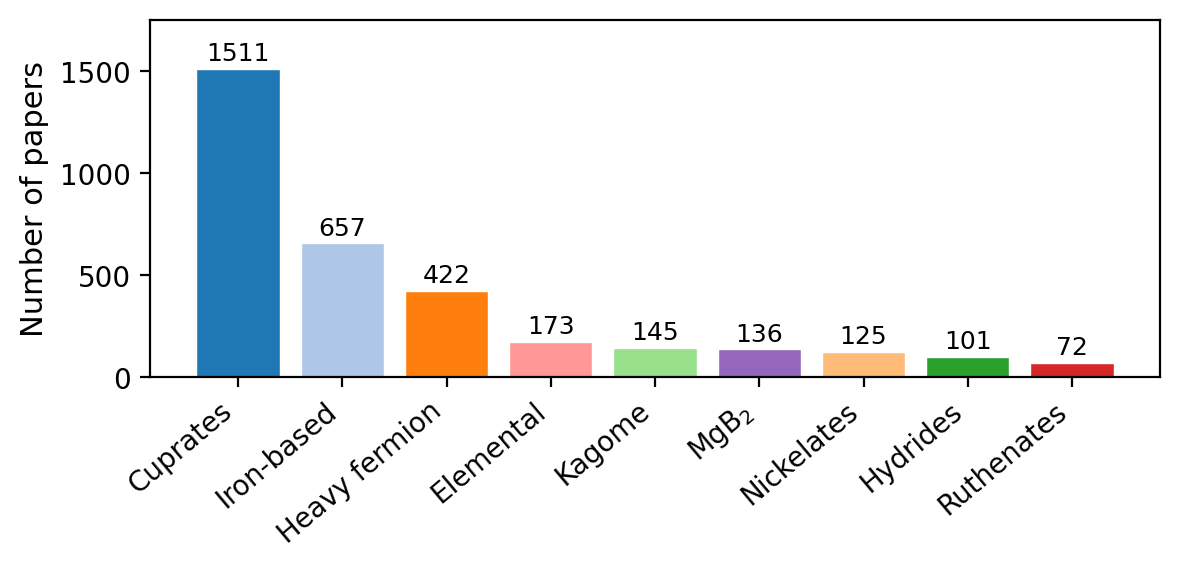

In [58]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from fig_common import *

rows = load_rows()

# --- YOU CONTROL THIS ---
KEEP_FAMS = ['cuprate', 'iron-based', 'heavy-fermion', 'elemental', 'kagome', 'MgB2', 'nickelate', 'hydrogen', 'ruthenate']

fam_counts = Counter(r["family"] for r in rows)

# only keep selected families (and preserve your order)
sorted_fams = [f for f in KEEP_FAMS if f in fam_counts]

vals = [fam_counts[f] for f in sorted_fams]
colors = [FAM_COLORS.get(f, "gray") for f in sorted_fams]

# --- vertical bar plot ---
fig, ax = plt.subplots(figsize=(6, 3))
display_fams = [LABEL_MAP.get(f, f) for f in sorted_fams]

bars = ax.bar(display_fams, vals, color=colors, edgecolor="white", linewidth=0.5)

# annotate
for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(vals) * 0.01,
                str(v), ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Number of papers", fontsize=11)
#ax.set_title("Fig. 2.1 – Superconductor Family", fontsize=13, fontweight="bold")

ax.set_ylim(0, max(vals) * 1.16)
#ax.grid(axis="y", alpha=0.3, linewidth=0.5)

plt.xticks(rotation=40, ha="right")
plt.tight_layout()
save_pdf(fig, 'fig2a_family_distribution')
plt.show()

### Fig.2b 
Count in multiple mechanisms existing for one paper.

Total non-zero mechanism assignments: 9740


Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2b_mechanism_distribution_nonzero.pdf


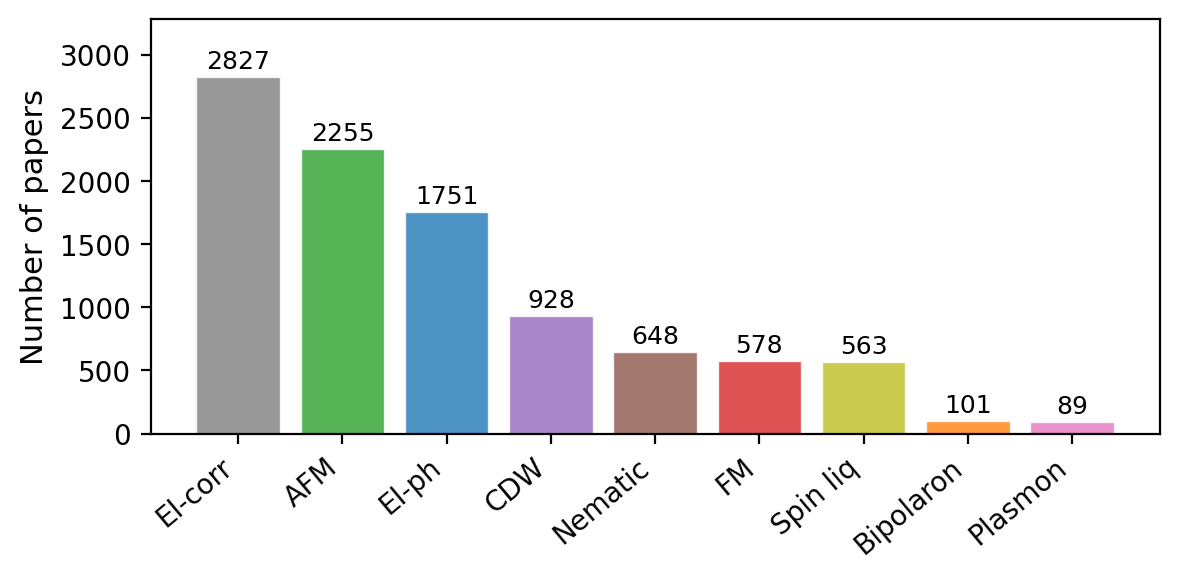

In [59]:
import json
import ast


def parse_scores(raw):
    if raw is None:
        return {}
    text = str(raw).strip()
    if text in ("", "{}", "nan", "None"):
        return {}
    try:
        return json.loads(text)
    except Exception:
        try:
            return ast.literal_eval(text)
        except Exception:
            return {}


# Count every non-zero mechanism per paper from opinion_scores_dict
mech_counts = Counter()
for r in rows:
    scores = parse_scores(r.get("opinion_scores_dict", ""))
    for mech in MECH_ORDER:
        try:
            v = float(scores.get(mech, 0.0) or 0.0)
        except Exception:
            v = 0.0
        if v != 0.0:
            mech_counts[mech] += 1

sorted_mechs = sorted(MECH_ORDER, key=lambda m: mech_counts.get(m, 0), reverse=True)
vals = [mech_counts.get(m, 0) for m in sorted_mechs]

print('Total non-zero mechanism assignments:', sum(vals))
colors = [MECH_COLORS[m] for m in sorted_mechs]
labels = [MECH_SHORT[m] for m in sorted_mechs]

fig, ax = plt.subplots(figsize=(6, 3))
# --- vertical bar ---
bars = ax.bar(labels, vals, color=colors,
              edgecolor="white", linewidth=0.5, alpha=0.8)

# annotate
for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + max(vals) * 0.01,
                str(v),
                ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Number of papers", fontsize=11)
ax.set_ylim(0, max(vals) * 1.16)
plt.xticks(rotation=40, ha="right")  # important for readability
fig.tight_layout()
save_pdf(fig, 'fig2b_mechanism_distribution_nonzero')
plt.show()



### Fig.2c

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2c_experimental_evidence_distribution.pdf


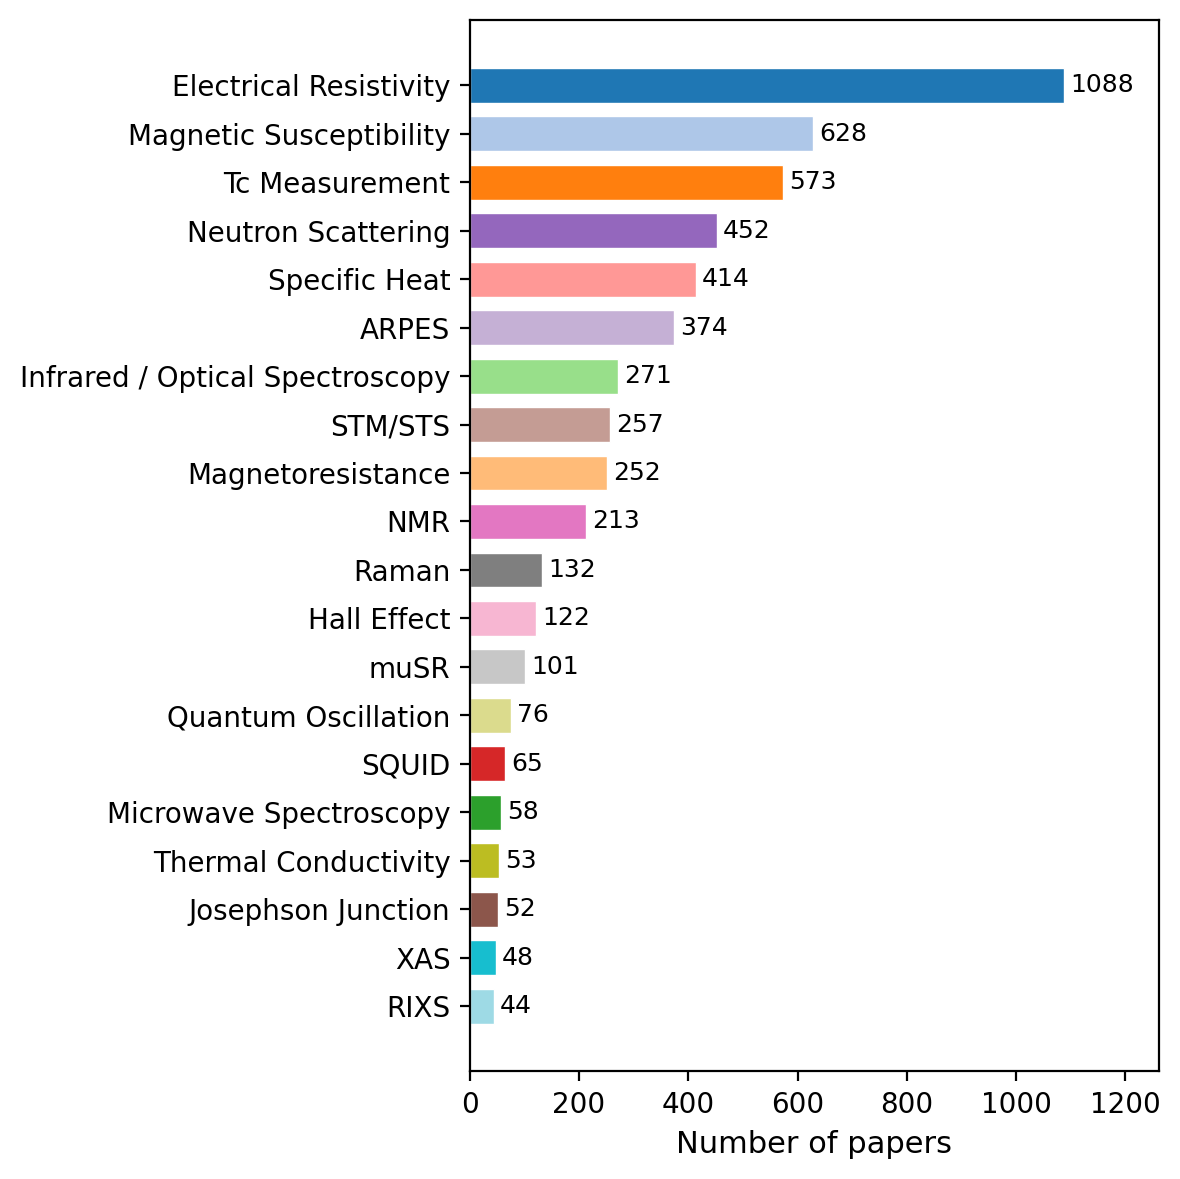

In [60]:
#!/usr/bin/env python3
"""Fig. 2.3_2 – Experimental evidence distribution (horizontal bar, multi-label)."""
from fig_common import *

METHODS = [
    "Electrical Resistivity", "Magnetic Susceptibility", "Tc Measurement",
    "Magnetoresistance", "Microwave Spectroscopy", "Infrared / Optical Spectroscopy",
    "SQUID", "Specific Heat", "Neutron Scattering", "ARPES",
    "Josephson Junction", "STM/STS", "NMR", "Hall Effect", "Raman",
    "muSR", "Thermal Conductivity", "Quantum Oscillation", "XAS", "RIXS"
]
# deleted: EELS, RHEED
COLORS = {m: plt.cm.tab20(i / (len(METHODS) - 1)) for i, m in enumerate(METHODS)}


def parse(val):
    text = str(val).strip()
    if text in ("none", "", "nan", "None"):
        return []
    return [m.strip() for m in text.split(" | ") if m.strip()]


rows = load_rows()
counts = Counter(m for r in rows for m in parse(r.get("evidence_experiment", "none")))
none_count = sum(1 for r in rows if not parse(r.get("evidence_experiment", "none")))

sorted_methods = sorted(METHODS, key=lambda m: counts.get(m, 0))
vals = [counts.get(m, 0) for m in sorted_methods]
colors = [COLORS[m] for m in sorted_methods]

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.barh(sorted_methods, vals, color=colors, edgecolor="white", linewidth=0.5, height=0.72)
for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
                str(v), va="center", ha="left", fontsize=9)
ax.set_xlabel("Number of papers", fontsize=11)
ax.set_xlim(0, max(vals) * 1.16)
#ax.grid(axis="x", alpha=0.3, linewidth=0.5)
fig.tight_layout()
save_pdf(fig, 'fig2c_experimental_evidence_distribution')
plt.show()



Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2c_computational_evidence_distribution.pdf


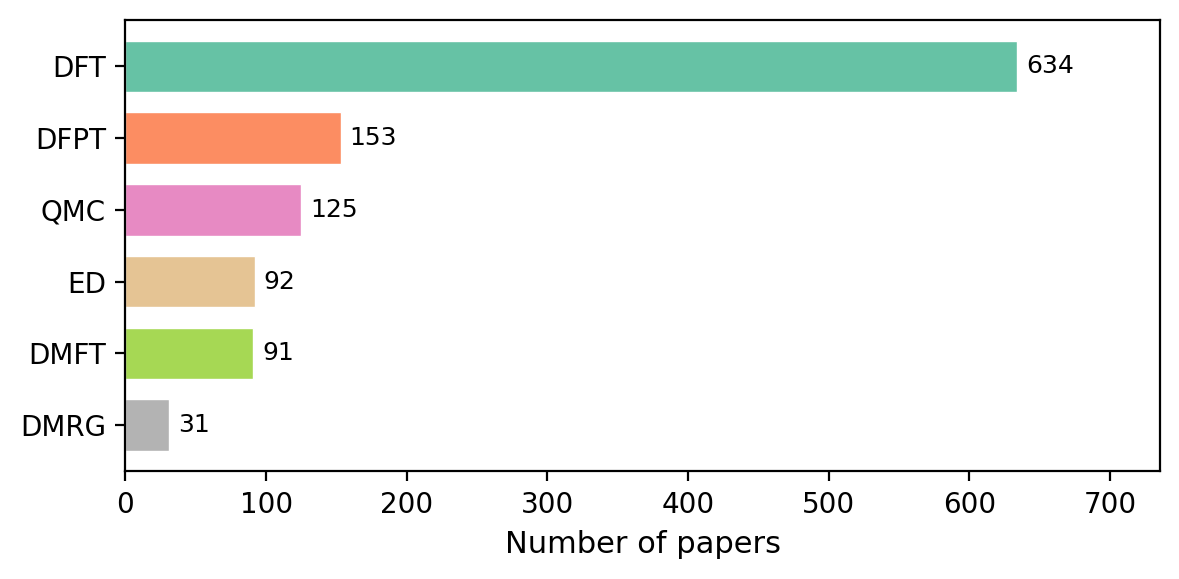

In [61]:
#!/usr/bin/env python3
"""Fig. 2.3_3 – Computational evidence distribution (horizontal bar, multi-label)."""
from fig_common import *

METHODS = ["DFT", "DFPT", "QMC", "DMFT", "ED", "DMRG"]
COLORS = {m: plt.cm.Set2(i / (len(METHODS) - 1)) for i, m in enumerate(METHODS)}


def parse(val):
    text = str(val).strip()
    if text in ("none", "", "nan", "None"):
        return []
    return [m.strip() for m in text.split(" | ") if m.strip()]


rows = load_rows()
counts = Counter(m for r in rows for m in parse(r.get("evidence_computation", "none")))
none_count = sum(1 for r in rows if not parse(r.get("evidence_computation", "none")))

sorted_methods = sorted(METHODS, key=lambda m: counts.get(m, 0))
vals = [counts.get(m, 0) for m in sorted_methods]
colors = [COLORS[m] for m in sorted_methods]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(sorted_methods, vals, color=colors, edgecolor="white", linewidth=0.5, height=0.72)
for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
                str(v), va="center", ha="left", fontsize=9)
ax.set_xlabel("Number of papers", fontsize=11)
ax.set_xlim(0, max(vals) * 1.16)
fig.tight_layout()
save_pdf(fig, 'fig2c_computational_evidence_distribution')
plt.show()



Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2c_theoretical_evidence_distribution.pdf


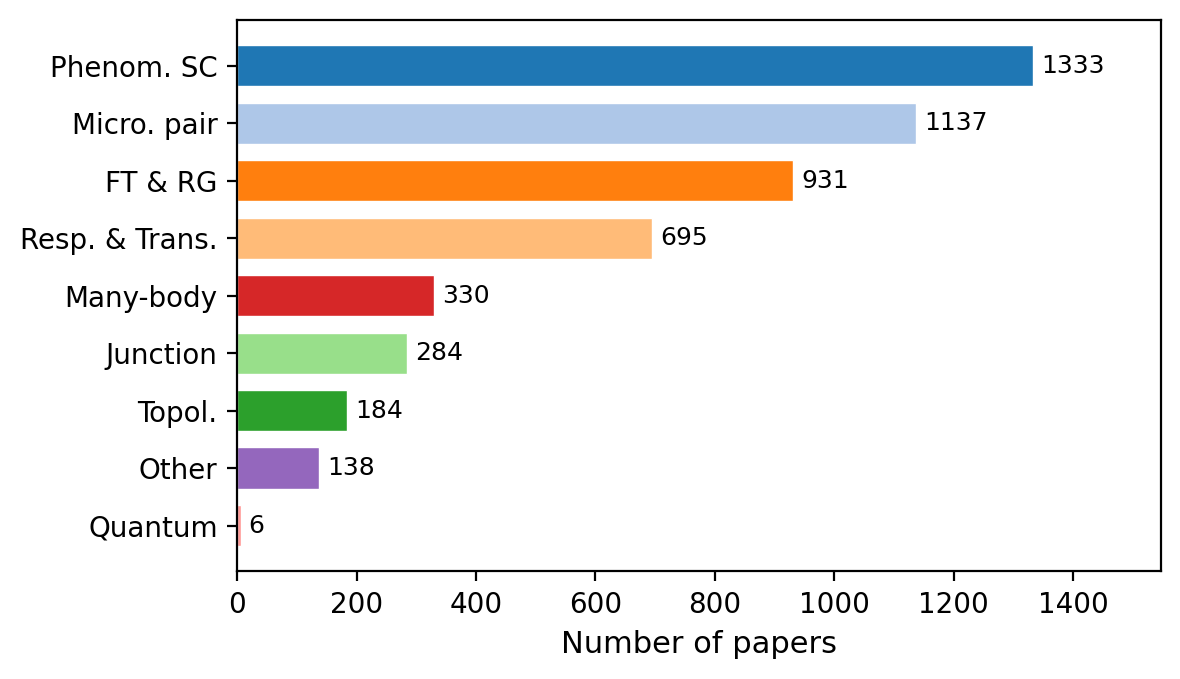

In [62]:
#!/usr/bin/env python3
"""Fig. 2.3 – Theoretical Evidence distribution (horizontal bar, multi-label)."""
from fig_common import *


def parse_theory(val):
    text = str(val).strip()
    if text in ("none", "", "nan", "None"):
        return []
    return [c.strip() for c in text.split(" | ") if c.strip()]


rows = load_rows()
ev_counts = Counter(
    cat
    for r in rows
    for cat in parse_theory(r.get("evidence_theory", "none"))
    if cat in EVIDENCE_CATS
)
none_count = sum(1 for r in rows if not parse_theory(r.get("evidence_theory", "none")))

sorted_evid = sorted(EVIDENCE_CATS, key=lambda e: ev_counts.get(e, 0))
vals = [ev_counts.get(e, 0) for e in sorted_evid]
colors = [EVID_COLORS[e] for e in sorted_evid]
labels = [EVID_SHORT[e] for e in sorted_evid]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(labels, vals, color=colors, edgecolor="white", linewidth=0.5, height=0.72)
for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
                str(v), va="center", ha="left", fontsize=9)
ax.set_xlabel("Number of papers", fontsize=11)
ax.set_xlim(0, max(vals) * 1.16)
fig.tight_layout()
save_pdf(fig, 'fig2c_theoretical_evidence_distribution')
plt.show()



### Fig.2d

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2d_publication_timeline_family.pdf


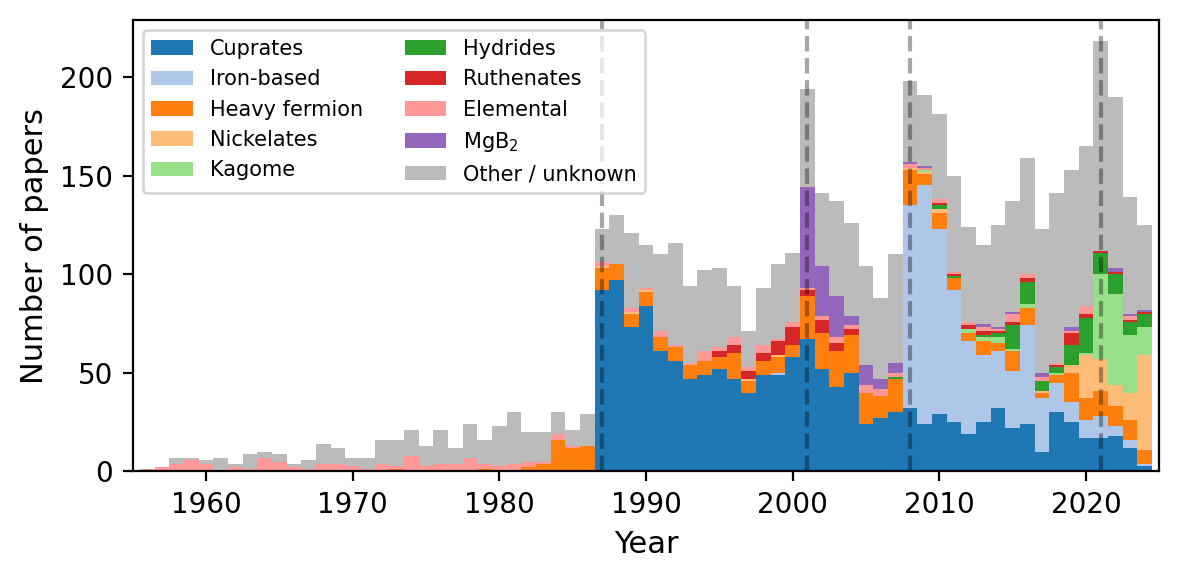

In [63]:
from fig_common import *
rows = load_rows()

STACK_FAMS = [
    "cuprate", "iron-based", "heavy-fermion", "nickelate",
    "kagome", "hydrogen", "ruthenate", "elemental", "MgB2"
]

year_fam = {f: Counter() for f in STACK_FAMS}
year_total = Counter()

for r in rows:
    if r["year"].strip().isdigit():
        y = int(r["year"])
        year_total[y] += 1

        fam = r["family"]
        if fam in STACK_FAMS:
            year_fam[fam][y] += 1

bottoms = np.zeros(len(YEARS))

fig, ax = plt.subplots(figsize=(6, 3))

for fam in STACK_FAMS:
    fvals = np.array([year_fam[fam].get(y, 0) for y in YEARS], dtype=float)
    ax.bar(
        YEARS, fvals,
        bottom=bottoms,
        color=FAM_COLORS.get(fam, "gray"),
        label=LABEL_MAP.get(fam, fam),
        width=1.0,
        edgecolor="none"
    )
    bottoms += fvals

rest = np.array([
    max(year_total.get(y, 0) - bottoms[i], 0)
    for i, y in enumerate(YEARS)
])

ax.bar(
    YEARS, rest,
    bottom=bottoms,
    color="#bbbbbb",
    label="Other / unknown",
    width=1.0,
    edgecolor="none"
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of papers", fontsize=11)

ax.set_xlim(1955, 2025)
#ax.grid(axis="y", alpha=0.3, linewidth=0.5)
#ax.spines[["top", "right"]].set_visible(False)
add_vlines(ax, xs=[1987, 2001, 2008, 2021], color="black", alpha=0.35)
ax.legend(fontsize=7.5, loc="upper left", ncol=2, framealpha=0.75)

fig.tight_layout()
save_pdf(fig, 'fig2d_publication_timeline_family')
plt.show()



### Fig.2e

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2e_publication_timeline_mechanism.pdf


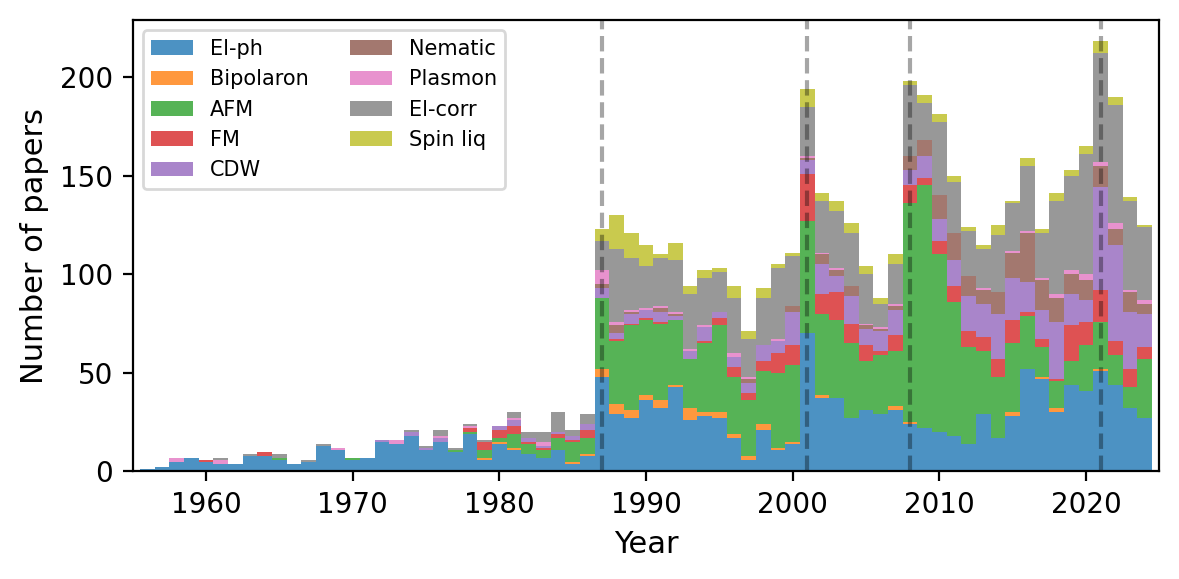

In [64]:
#!/usr/bin/env python3
"""Fig. 2.5 – Publication timeline stacked by mechanism."""
from fig_common import *

rows = load_rows()
year_mech = {m: Counter() for m in MECH_ORDER}
for r in rows:
    if r["year"].strip().isdigit() and r["mechanism"] in MECH_ORDER:
        year_mech[r["mechanism"]][int(r["year"])] += 1

bottoms = np.zeros(len(YEARS))

fig, ax = plt.subplots(figsize=(6, 3))
for mech in MECH_ORDER:
    mvals = np.array([year_mech[mech].get(y, 0) for y in YEARS], dtype=float)
    ax.bar(YEARS, mvals, bottom=bottoms, color=MECH_COLORS[mech],
           label=MECH_SHORT[mech], width=1.0, edgecolor="none", alpha=0.8)
    bottoms += mvals

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of papers", fontsize=11)
ax.legend(fontsize=7.5, loc="upper left", ncol=2, framealpha=0.75)
ax.set_xlim(1955, 2025)
#ax.grid(axis="y", alpha=0.3, linewidth=0.5)
add_vlines(ax, xs=[1987, 2001, 2008, 2021], color="black", alpha=0.35)
#ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_pdf(fig, 'fig2e_publication_timeline_mechanism')
plt.show()



### Fig.2f

Valid papers with non-zero opinion signal: 5446
Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2f_cumulative_opinion_max_normalized.pdf


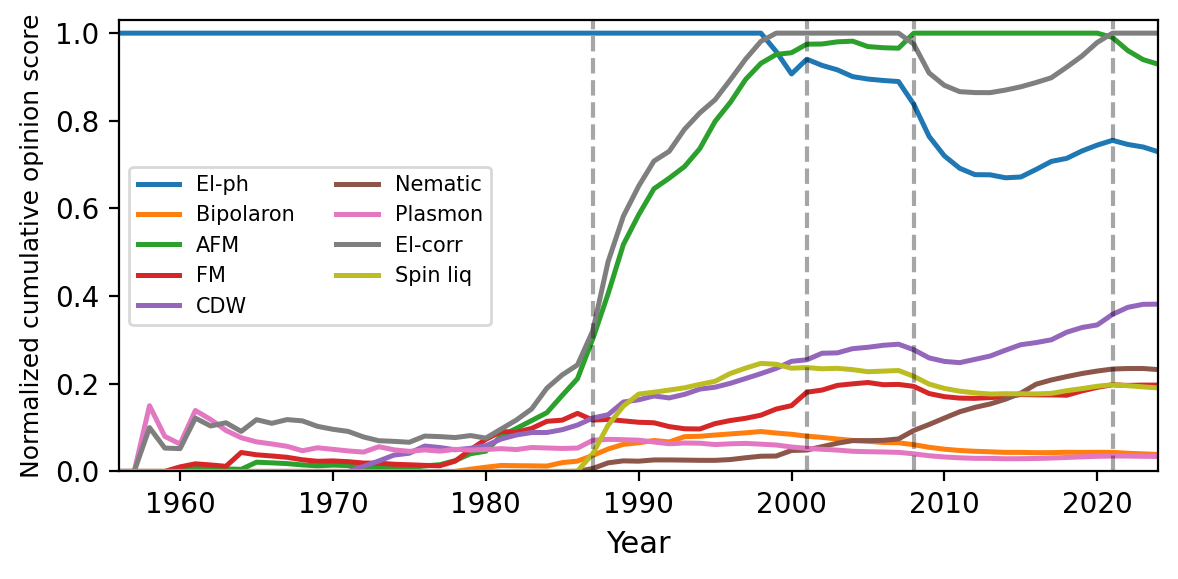

In [65]:
from fig_common import *
import json
import ast

rows = load_rows()
MECH_KEYS = list(MECH_ORDER)


def parse_scores(raw):
    if raw is None:
        return {}
    text = str(raw).strip()
    if text in ("", "{}", "nan", "None"):
        return {}
    try:
        return json.loads(text)
    except Exception:
        try:
            return ast.literal_eval(text)
        except Exception:
            return {}


valid_rows = []
for r in rows:
    year_text = str(r.get("year", "")).strip()
    if not year_text.isdigit():
        continue

    scores = parse_scores(r.get("opinion_scores_dict", ""))
    if not scores:
        continue

    mech_scores = {}
    has_signal = False
    for k in MECH_KEYS:
        try:
            v = float(scores.get(k, 0.0) or 0.0)
        except Exception:
            v = 0.0
        mech_scores[k] = v
        if v != 0.0:
            has_signal = True

    if has_signal:
        valid_rows.append((int(year_text), mech_scores))

print(f"Valid papers with non-zero opinion signal: {len(valid_rows)}")

if not valid_rows:
    raise ValueError("No valid rows found with non-zero opinion scores.")

YEAR_START = min(y for y, _ in valid_rows)
YEAR_END = max(y for y, _ in valid_rows)
years = np.arange(YEAR_START, YEAR_END + 1)

# yearly summed opinion score for each mechanism
yearly_scores = {k: np.zeros(len(years), dtype=float) for k in MECH_KEYS}
for y, score_dict in valid_rows:
    yi = y - YEAR_START
    for k in MECH_KEYS:
        yearly_scores[k][yi] += score_dict.get(k, 0.0)

# cumulative opinion score over time
cumulative_scores = {k: np.cumsum(yearly_scores[k]) for k in MECH_KEYS}

# relative cumulative score: divide each year by the max mechanism score that year
stacked = np.vstack([cumulative_scores[k] for k in MECH_KEYS])
yearly_max = stacked.max(axis=0)
yearly_max[yearly_max == 0] = 1.0

relative_scores = {k: cumulative_scores[k] / yearly_max for k in MECH_KEYS}

fig, ax = plt.subplots(figsize=(6, 3))
for k in MECH_KEYS:
    ax.plot(
        years,
        relative_scores[k],
        label=MECH_SHORT.get(k, k),
        color=MECH_COLORS.get(k, None),
        linewidth=1.8,
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Normalized cumulative opinion score", fontsize=9)
ax.set_xlim(int(years.min()), int(years.max()))
ax.set_ylim(0, 1.03)
add_vlines(ax, xs=[1987, 2001, 2008, 2021], color="black", alpha=0.35)
#ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(fontsize=7.5, ncol=2, framealpha=0.75)
fig.tight_layout()
save_pdf(fig, 'fig2f_cumulative_opinion_max_normalized')
plt.show()



Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig2f_cumulative_opinion_unnormalized.pdf


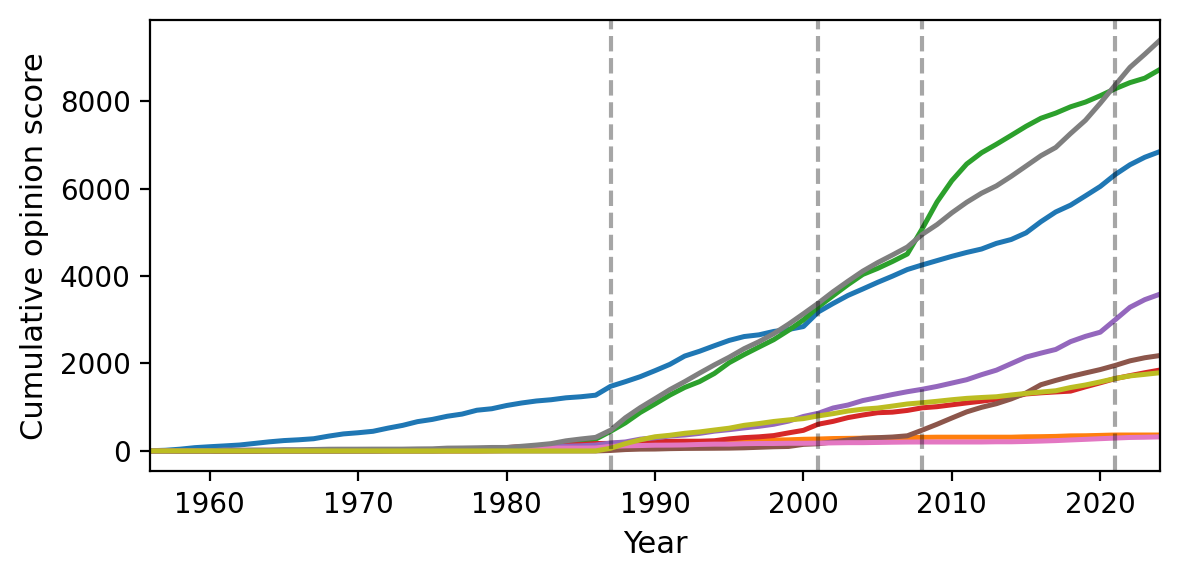

In [66]:
# Un-normalized cumulative opinion score (strictly non-decreasing)
# Reuse computed variables if Fig.2f cell has been run; rebuild if needed.
if not all(name in globals() for name in ["yearly_scores", "years", "MECH_KEYS"]):
    from fig_common import *
    import json
    import ast

    rows = load_rows()
    MECH_KEYS = list(MECH_ORDER)

    def parse_scores(raw):
        if raw is None:
            return {}
        text = str(raw).strip()
        if text in ("", "{}", "nan", "None"):
            return {}
        try:
            return json.loads(text)
        except Exception:
            try:
                return ast.literal_eval(text)
            except Exception:
                return {}

    valid_rows = []
    for r in rows:
        year_text = str(r.get("year", "")).strip()
        if not year_text.isdigit():
            continue

        scores = parse_scores(r.get("opinion_scores_dict", ""))
        if not scores:
            continue

        mech_scores = {}
        has_signal = False
        for k in MECH_KEYS:
            try:
                v = float(scores.get(k, 0.0) or 0.0)
            except Exception:
                v = 0.0
            mech_scores[k] = v
            if v != 0.0:
                has_signal = True

        if has_signal:
            valid_rows.append((int(year_text), mech_scores))

    YEAR_START = min(y for y, _ in valid_rows)
    YEAR_END = max(y for y, _ in valid_rows)
    years = np.arange(YEAR_START, YEAR_END + 1)

    yearly_scores = {k: np.zeros(len(years), dtype=float) for k in MECH_KEYS}
    for y, score_dict in valid_rows:
        yi = y - YEAR_START
        for k in MECH_KEYS:
            yearly_scores[k][yi] += score_dict.get(k, 0.0)

raw_cumulative_scores = {}
for k in MECH_KEYS:
    # Guard against any unexpected negative yearly values.
    per_year_nonneg = np.maximum(yearly_scores[k], 0.0)
    cum = np.cumsum(per_year_nonneg)
    raw_cumulative_scores[k] = np.maximum.accumulate(cum)

fig, ax = plt.subplots(figsize=(6, 3))
for k in MECH_KEYS:
    ax.plot(
        years,
        raw_cumulative_scores[k],
        label=MECH_SHORT.get(k, k),
        color=MECH_COLORS.get(k, None),
        linewidth=1.8,
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Cumulative opinion score", fontsize=11)
ax.set_xlim(int(years.min()), int(years.max()))
add_vlines(ax, xs=[1987, 2001, 2008, 2021], color="black", alpha=0.35)
#ax.grid(True, alpha=0.3, linewidth=0.5)
#ax.legend(fontsize=7.5, loc="upper left", ncol=2, framealpha=0.75)
fig.tight_layout()
save_pdf(fig, 'fig2f_cumulative_opinion_unnormalized')
plt.show()